# Clustering Tutorial: K-Means and DBSCAN

**Instructor: Dr. Arun B Ayyar**

**Date:** 17.02.2025 AN

---

This notebook contains practical exercises on K-Means and DBSCAN clustering algorithms with diverse datasets.

Each problem includes:
- **Problem statement** with dataset description
- **Hints** including scikit-learn functions to use
- **Complete solution** with code and visualizations

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_blobs, make_moons, make_circles, load_iris, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## Problem 1: Iris Dataset (4D → 2D with PCA)

**Dataset:** Iris flower measurements (150 samples, 4 features)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Standardize the features
2. Use the elbow method to find optimal k (test k=2 to 10)
3. Apply K-Means with optimal k
4. Reduce to 2D using PCA for visualization
5. Visualize clusters and calculate silhouette score

**Hints:**
- Use `load_iris()` from sklearn.datasets
- Use `StandardScaler()` for standardization
- Use `KMeans(n_clusters=k, random_state=42)` for clustering
- Plot inertia (WCSS) vs k for elbow method
- Use `PCA(n_components=2)` for dimensionality reduction
- Use `silhouette_score()` to evaluate clustering quality

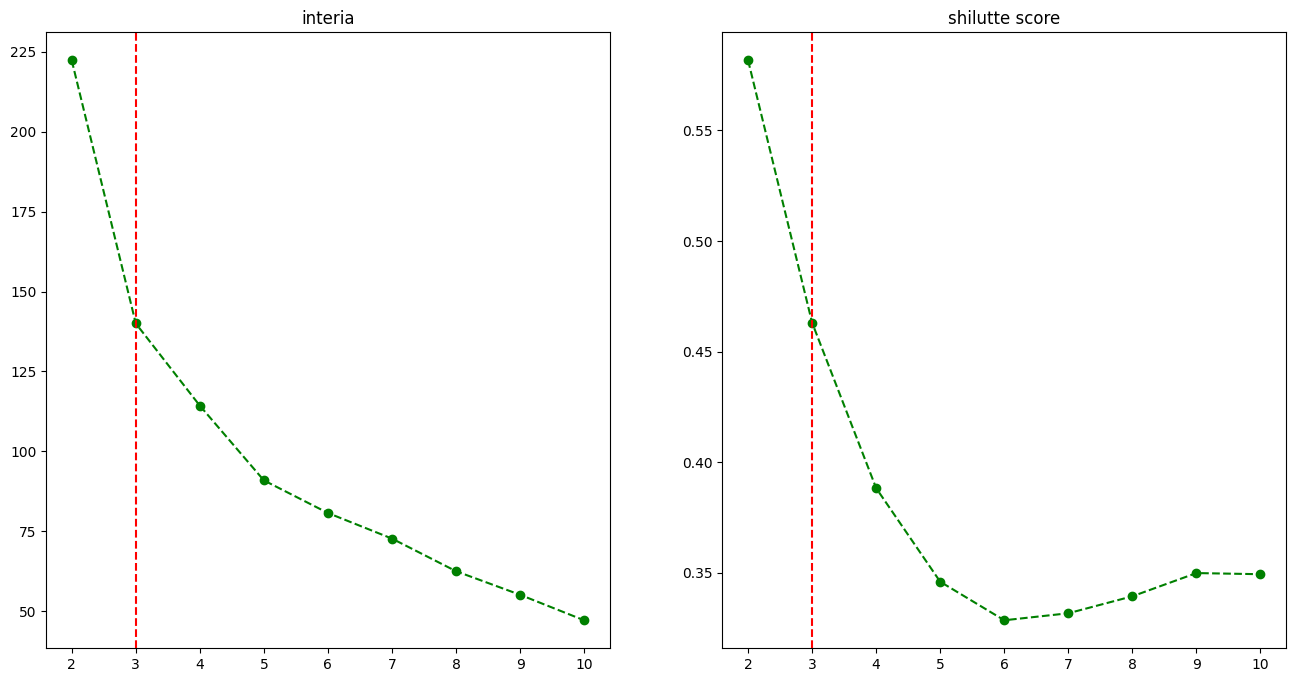

In [10]:
# steps :
# load dataset + read dataset
# standardize dataset
# apply kmeans - interia + shilutte score
# apply pca

# load dataset + read dataset
from sklearn.datasets import load_iris
iris = load_iris()
X_iris = iris.data
y_trye = iris.target

# standardize dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)


# apply kmeans - interia + shilutte score
interia = []
shilutte_score = []
k_range = range(2,11)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
for i in range(2,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=5)
    kmeans.fit(X_scaled)
    interia.append(kmeans.inertia_)
    shilutte_score.append(silhouette_score(X=X_scaled, labels=kmeans.labels_))

# visualize the interia  and shilutte score
import matplotlib.pyplot as plt
fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(16,8))
axes[0].plot(k_range,interia,marker='o',color = 'green',linestyle='dashed')
axes[0].set_title("interia")
axes[0].axvline(x=3,color='r',linestyle='--')

axes[1].plot(k_range,shilutte_score,marker='o',color='green',linestyle='dashed')
axes[1].set_title("shilutte score")
axes[1].axvline(x=3,color='r',linestyle='--')

# cluster number = 3 is better

# pca with n_components = 2
from sklearn.decomposition import PCA
pca = PCA(n_components=2,random_state=42)
X_scaled_pca = pca.fit_transform(X_scaled)

In [11]:
# Load and prepare data
iris = load_iris()
X_iris = iris.data
y_true = iris.target

variance i.e. eigen value : [2.93808505 0.9201649 ]
data coverage : [0.72962445 0.22850762]


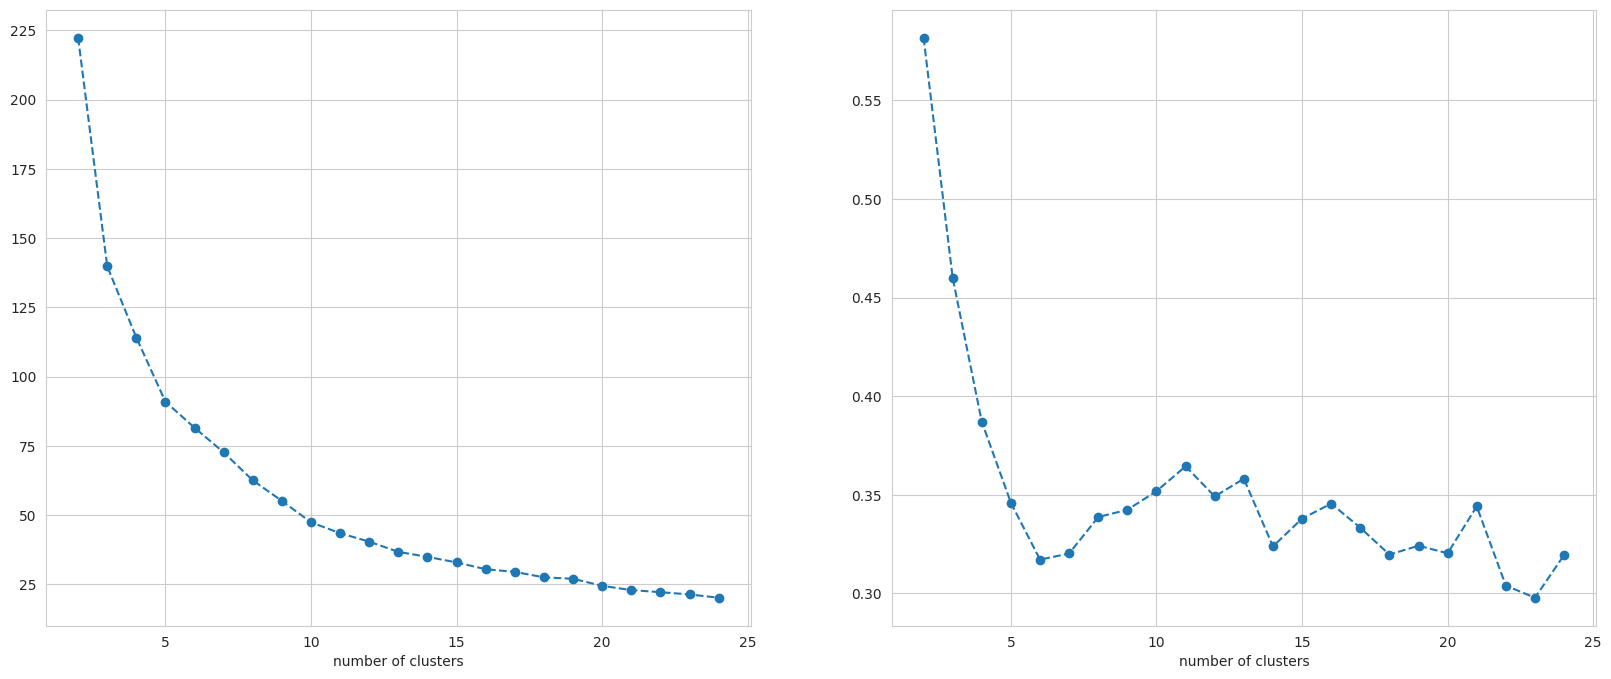

In [12]:
# Standardize
# Your code here
# Apply clustering algorithm and visualize results

# steps :
# 1. load the dataset
# 2. read the dataset
# 3. standardize the dataset
# 4. apply elbow method

# call pca
# result visualize

# 1.load the dataset
from sklearn.datasets import load_iris
iris = load_iris()
#iris = load_iris(as_frame=True)

# 2. read the dataset
X_data = iris.data
y_traget = iris.target
feature_names = iris.feature_names
target_names = iris.target_names
#data_frame = iris.frame

# 3.standardize the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_data_scaled = scaler.fit_transform(X_data)

# 4. apply elbow method
interias = []
shilutte_score = []
k_range = range(2,25)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for i in range(2,25):
    kmeans = KMeans(n_clusters = i , init='k-means++' ,  n_init=10, random_state=42)
    kmeans.fit(X_data_scaled)
    interias.append(kmeans.inertia_)
    shilutte_score.append(silhouette_score(X_data_scaled,kmeans.labels_))

# plotting
import matplotlib.pyplot as plt
fig ,axes = plt.subplots(nrows=1,ncols=2,figsize=(20,8))
axes[0].plot(k_range,interias,marker='o', linestyle='dashed')
axes[0].set_xlabel("number of clusters")

axes[1].plot(k_range,shilutte_score,marker='o', linestyle='dashed')
axes[1].set_xlabel("number of clusters")
#shilutte_score
#interias

kmeans = KMeans(n_clusters = 3 , init='k-means++' ,  n_init=10, random_state=42)
kmeans.fit(X_data_scaled)
labels = kmeans.labels_ # kmeans.fit_predict

# call pca
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_data_scaled)

# pca result visualization
print(f"variance i.e. eigen value : {pca.explained_variance_}")
print(f"data coverage : {pca.explained_variance_ratio_}")

In [13]:
#help(plt.subplots)

## Problem 2: Customer Segmentation (Synthetic Data)

**Dataset:** Customer data with Annual Income and Spending Score (200 samples)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Use elbow method to find optimal k
2. Apply K-Means clustering
3. Visualize and interpret customer segments
4. Provide business insights for each segment

**Hints:**
- Use `make_blobs(n_samples=200, n_features=2, centers=5, cluster_std=1.0, random_state=42)`
- Features represent: [Annual Income (k$), Spending Score (1-100)]
- Use `KMeans(n_clusters=k, random_state=42)`
- Calculate cluster statistics (mean income, mean spending) for each segment

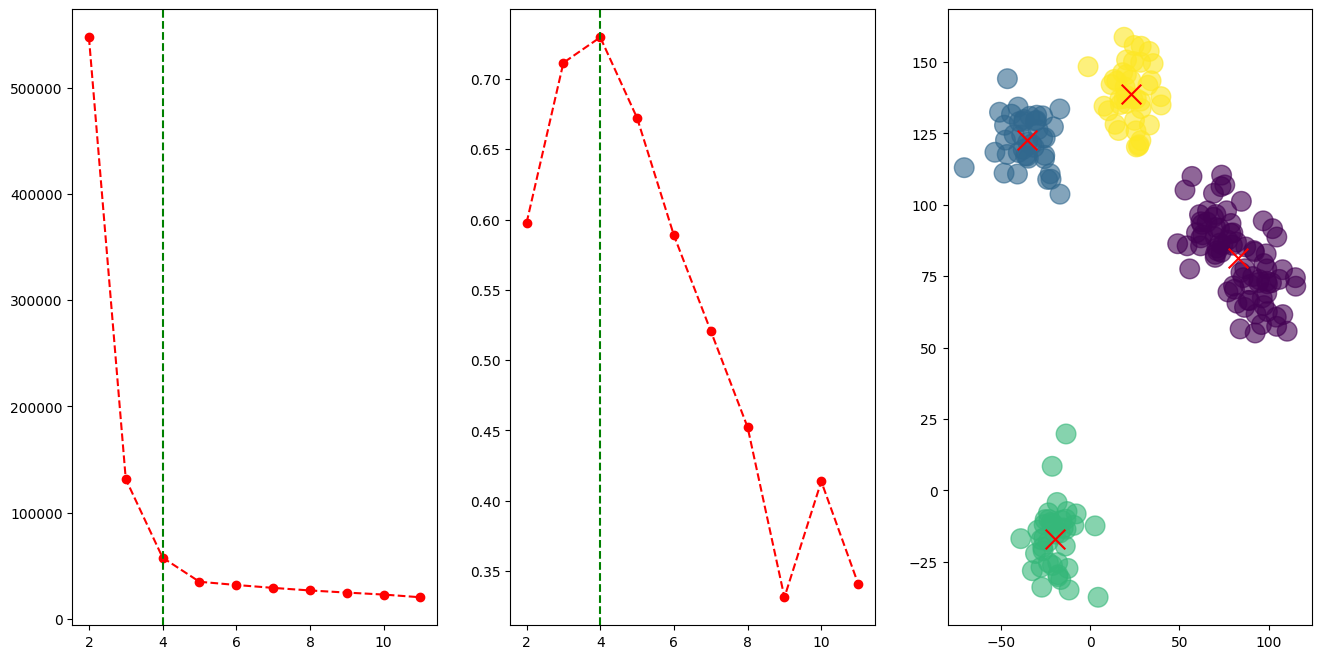

In [24]:
# step
# load  +  read dataset
# apply elbow technique
# visaulize the results

# load + read dataset
from  sklearn.datasets import make_blobs
X_customers , y_customers = make_blobs(n_samples=200, n_features=2, centers=5, cluster_std=1.0,  random_state=42)

# Scale to realistic ranges
X_customers[:, 0] = X_customers[:, 0] * 10 + 50  # Annual Income: 30-70k
X_customers[:, 1] = X_customers[:, 1] * 10 + 50  # Spending Score: 30-70

# apply elbow technique
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
interia = []
sil_score = []
k_range = range(2,12)

for i in range(2,12):
    kmeans= KMeans(n_clusters=i,  init='k-means++', n_init=5)
    kmeans.fit(X_customers)
    interia.append(kmeans.inertia_)
    sil_score.append(silhouette_score(X=X_customers, labels=kmeans.labels_))

#visualize the score
import matplotlib.pyplot as plt
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,8))
interia_plot = axes[0].plot(k_range,interia,marker='o',color='red',linestyle='dashed')
axes[0].axvline(x=4,color='green',linestyle='--')
sil_plot = axes[1].plot(k_range,sil_score,marker='o',color='red',linestyle='dashed')
axes[1].axvline(x=4,color='green',linestyle='--')

# clustering for k= 4
kmeans= KMeans(n_clusters=4,  init='k-means++', n_init=5)
kmeans.fit(X_customers)
labels= kmeans.labels_
centroid = kmeans.cluster_centers_
cluster_seg = axes[2].scatter(X_customers[:, 0],X_customers[:, 1],c=labels,cmap = 'viridis',s=200,alpha = 0.6)
axes[2].scatter(centroid[:,0],centroid[:,1],marker='x',s=200,c='red')

In [17]:
#help(make_blobs)
#help(KMeans)
#help(silhouette_score)

In [14]:
# Generate customer data
X_customers, _ = make_blobs(n_samples=200, n_features=2, centers=5, cluster_std=1.0, random_state=42)

# Scale to realistic ranges
X_customers[:, 0] = X_customers[:, 0] * 10 + 50  # Annual Income: 30-70k
X_customers[:, 1] = X_customers[:, 1] * 10 + 50  # Spending Score: 30-70



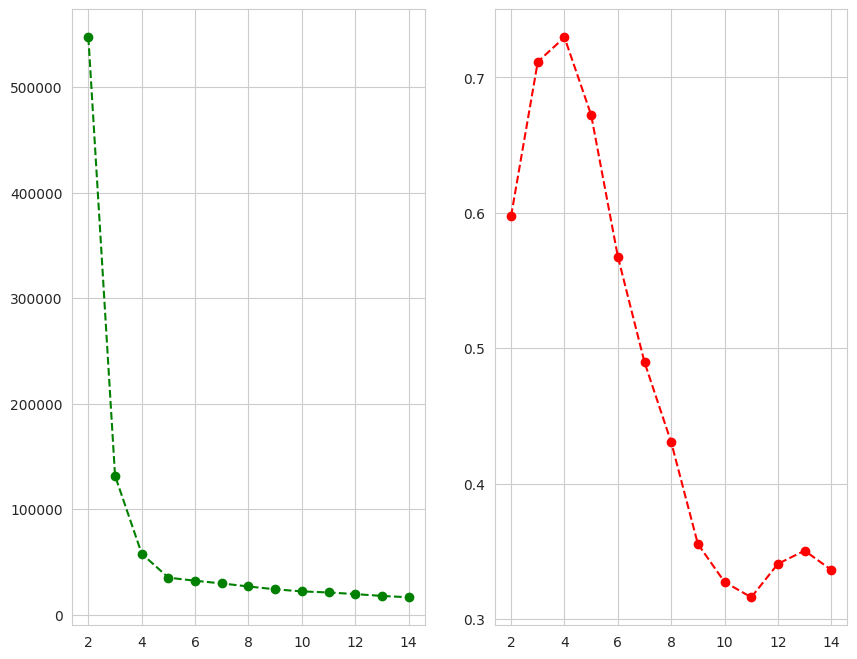

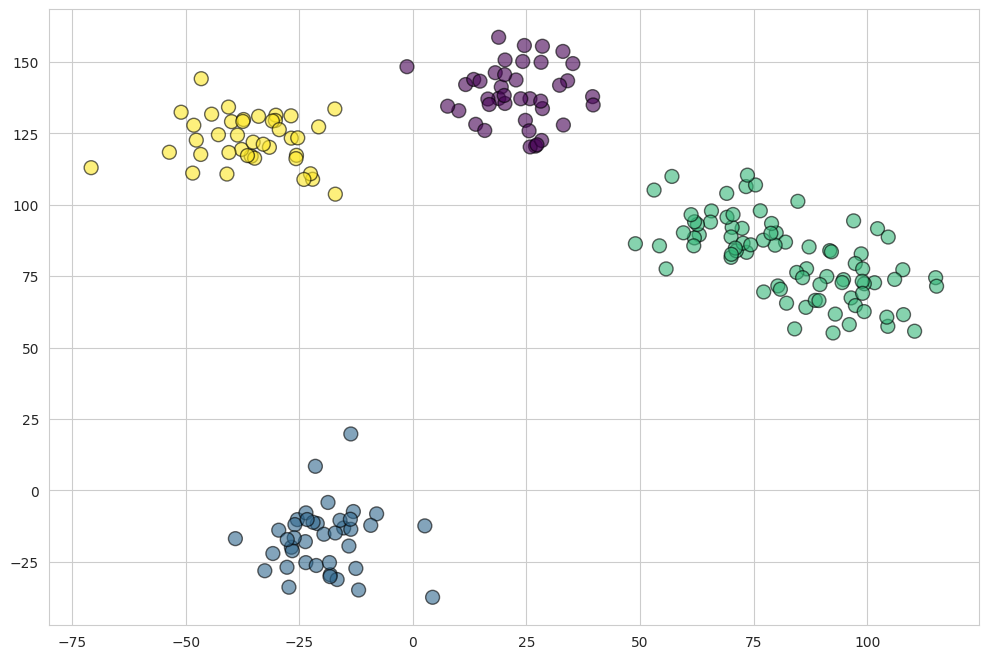

In [15]:
# Your code here
# Apply clustering algorithm and visualize results

# load dataset
# read dataset
# elbow method
# cluserting for k
# business insights

# load dataset
from sklearn.datasets import make_blobs
X_customers,_ = make_blobs(n_samples=200,n_features=2,centers=5,cluster_std=1.0,random_state=42)

# scale to realistic ranges
X_customers[:,0] = X_customers[:,0]*10 + 50 # Annual Income: 30-70k
X_customers[:,1] = X_customers[:,1]*10 + 50 # Spending Score: 30-70

# elbow technique
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
interia = []
shilutte_score = []
k_range = range(2,15)

for i in range(2,15):
    kmeans = KMeans(n_clusters = i,init='k-means++', n_init= 5,random_state=42)
    kmeans.fit(X_customers)
    interia.append(kmeans.inertia_)
    shilutte_score.append(silhouette_score(X= X_customers,labels= kmeans.labels_,random_state=42))

# visulaization
import matplotlib.pyplot as plt
fig,axes = plt.subplots(nrows = 1, ncols = 2,figsize=(10,8))
axes[0].plot(k_range,interia,color='green', marker='o', linestyle='dashed')
axes[1].plot(k_range,shilutte_score,color='red', marker='o', linestyle='dashed')

# apply k-means
# n_clusters = 4 from elbow technique
kmeans = KMeans(n_clusters = 4, init='k-means++', n_init=5,random_state=42)
kmeans.fit(X_customers)
centers = kmeans.cluster_centers_
mean_income = centers[:,0]
mean_spending = centers[:,1]

lables = kmeans.labels_
# Visualize
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_customers[:, 0], X_customers[:, 1], c=lables, cmap='viridis', s=100, alpha=0.6, edgecolors='k')

## Problem 3: Anisotropic Blobs (Stretched Clusters)

**Dataset:** 3 clusters with different shapes and orientations (300 samples)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Apply K-Means with k=3
2. Visualize the results
3. Analyze why K-Means struggles with this data

**Hints:**
- Use `make_blobs()` with `cluster_std=[1.0, 2.5, 0.5]` for different cluster spreads
- Apply transformation matrix to create anisotropy
- Use `KMeans(n_clusters=3, random_state=42)`
- Compare cluster assignments with true labels
- Note: K-Means assumes spherical clusters!

In [16]:
# Generate anisotropic data
X_aniso, y_aniso = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=[1.0, 2.5, 0.5], random_state=42)

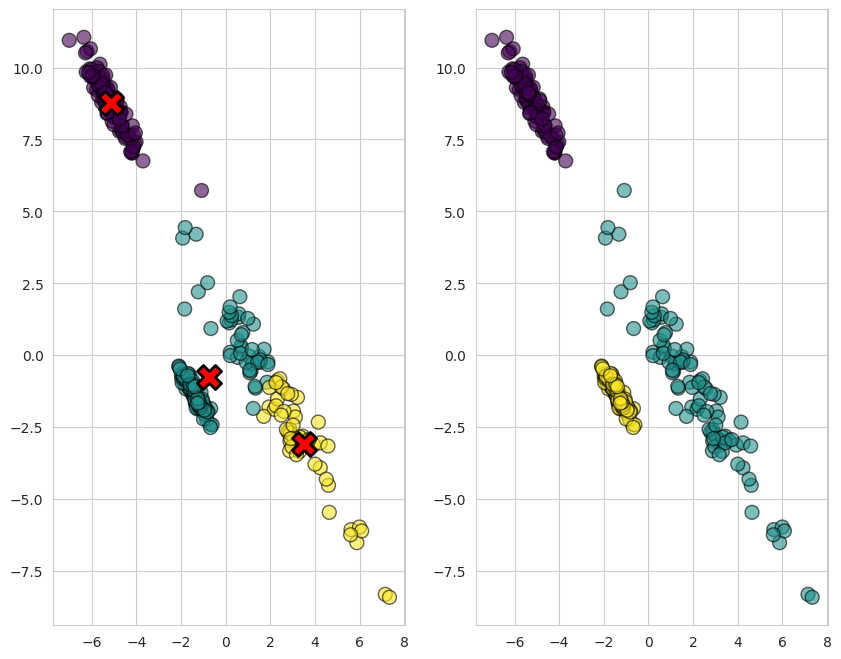

In [17]:
# Your code here
# Apply clustering algorithm and visualize results
# data loading
# data reading
# cluserting for k = 3
# business insights

#  data loading
import numpy as np
from sklearn.datasets import make_blobs
X_aniso,y_aniso = make_blobs(n_samples= 300 , n_features = 2, centers = 3, cluster_std=[1.0, 2.5, 0.5] , random_state = 42)
transformation = np.array([[0.6, -0.6],
                           [-0.4, 0.8]])
X_aniso = X_aniso@transformation

# KMenas = 3 apply
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,init='k-means++', n_init=5,random_state=42)
kmeans.fit(X_aniso)
labels = kmeans.labels_

# visulaization
import matplotlib.pyplot as plt
fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(10,8))
scatter_predicted = axes[0].scatter(X_aniso[:,0],X_aniso[:,1],s=100,c=labels,cmap='viridis',alpha=0.6, edgecolors='k')
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')
scatter_original = axes[1].scatter(X_aniso[:,0],X_aniso[:,1],s=100,c=y_aniso,cmap='viridis',alpha=0.6, edgecolors='k')

## Problem 4: Concentric Circles (Non-Convex Clusters)

**Dataset:** Two concentric circles (400 samples)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Apply K-Means with k=2
2. Visualize and analyze the failure
3. Explain why K-Means fails on this data

**Hints:**
- Use `make_circles(n_samples=400, factor=0.5, noise=0.05, random_state=42)`
- Use `KMeans(n_clusters=2, random_state=42)`
- K-Means cannot handle non-convex shapes!
- This is where DBSCAN or Spectral Clustering excel

In [18]:
# Generate concentric circles
X_circles, y_circles = make_circles(n_samples=400, factor=0.5, noise=0.05, random_state=42)


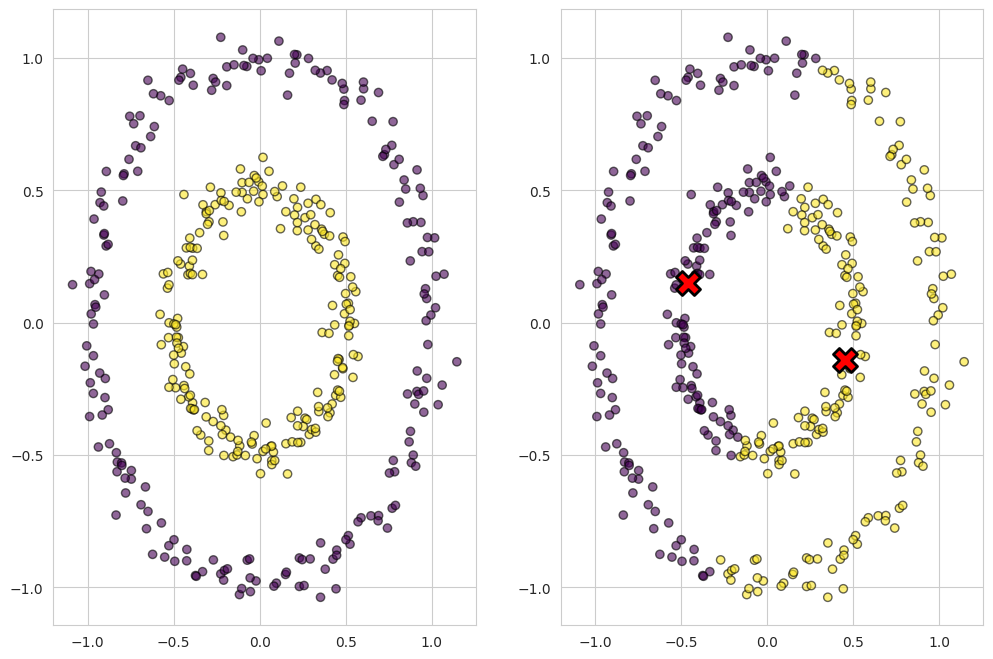

In [19]:
# Your code here
# Apply clustering algorithm and visualize results

# load dataset
# read dataset
# apply kmeans with 2
# visualize the result

# load dataset and read dataset
from sklearn.datasets import make_circles
X_circles,y_circles = make_circles(n_samples=400, factor=0.5, noise=0.05, random_state = 42)

# apply kmeans with 2
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2 , init='k-means++', n_init=5,random_state=42)
kmeans.fit(X_circles)
labels = kmeans.labels_
cluster_centers = kmeans.cluster_centers_

# visualize the result
import matplotlib.pyplot as plt
fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(12,8))
original_cluster = axes[0].scatter(X_circles[:,0],X_circles[:,1],c= y_circles,cmap='viridis',alpha=0.6, edgecolors='k')
kmeans_cluster = axes[1].scatter(X_circles[:,0],X_circles[:,1],c= labels,cmap='viridis',alpha=0.6, edgecolors='k')
kmeans_centroid = axes[1].scatter(cluster_centers[:,0],cluster_centers[:,1], c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')


## Problem 5: Crescent Moons (Non-Convex Shapes)

**Dataset:** Two interleaving crescent moons (300 samples)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Apply both K-Means and DBSCAN
2. Compare their performance
3. Tune DBSCAN parameters (eps and min_samples)

**Hints:**
- Use `make_moons(n_samples=300, noise=0.05, random_state=42)`
- For K-Means: `KMeans(n_clusters=2, random_state=42)`
- For DBSCAN: `DBSCAN(eps=0.2, min_samples=5)`
- Try different eps values: [0.1, 0.2, 0.3]
- Noise points in DBSCAN are labeled as -1

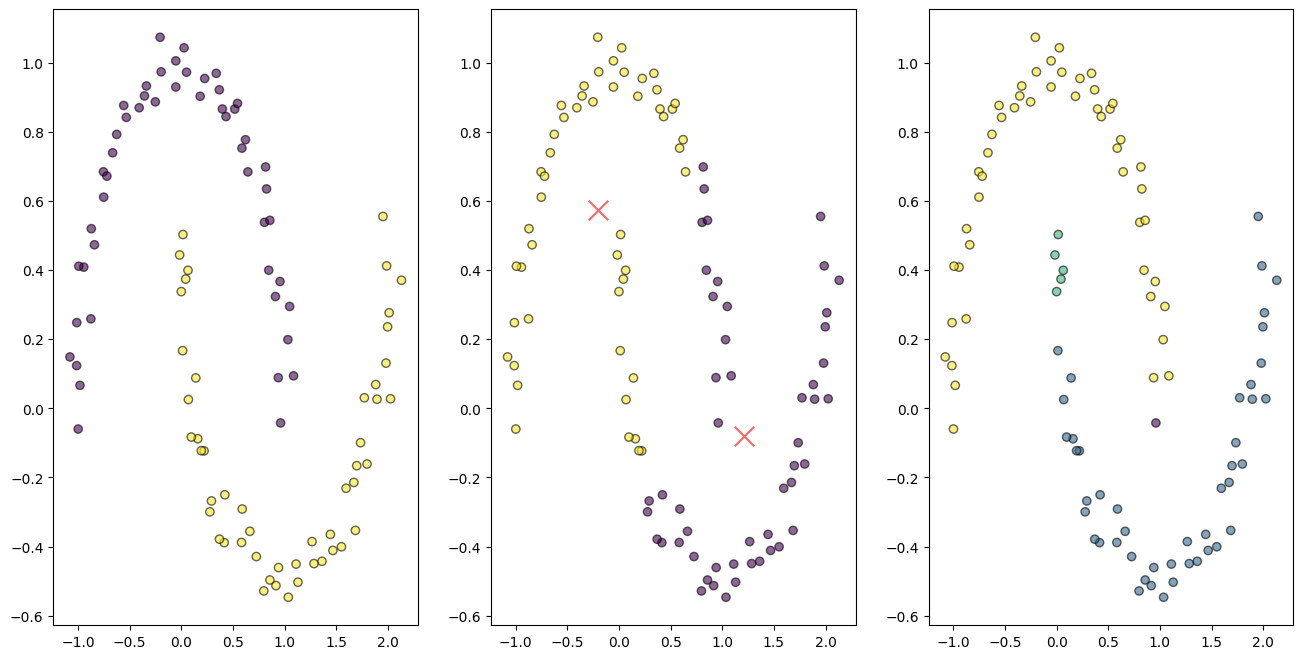

In [23]:
# steps
# load the dataset + read the dataset
# apply kmeans
# apply DBSCAN
# visualize the results

# load the dataset + read the dataset
from sklearn.datasets import make_moons
X_moons,y_moons = make_moons(n_samples=100,noise=0.05, random_state=42)

# apply kmeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2,init='k-means++', n_init=5)
kmeans.fit(X_moons)
labels = kmeans.labels_

# apply DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5, metric='euclidean')
dbscan.fit(X_moons)
dblabels = dbscan.labels_
centroid = kmeans.cluster_centers_

# visualize the result
import matplotlib.pyplot as plt
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,8))

original_cluster = axes[0].scatter(X_moons[:,0],X_moons[:,1],c=y_moons,cmap='viridis',alpha=0.6,edgecolor='k')

kmeans_cluster = axes[1].scatter(X_moons[:,0],X_moons[:,1],c=labels,cmap='viridis',alpha=0.6,edgecolor='k')
axes[1].scatter(centroid[:,0],centroid[:,1],c='red',alpha=0.6,marker='x',s=200)

db_cluster = axes[2].scatter(X_moons[:,0],X_moons[:,1],c=dblabels,cmap='viridis',alpha=0.6,edgecolor='k')

In [20]:
# Generate moons data
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)


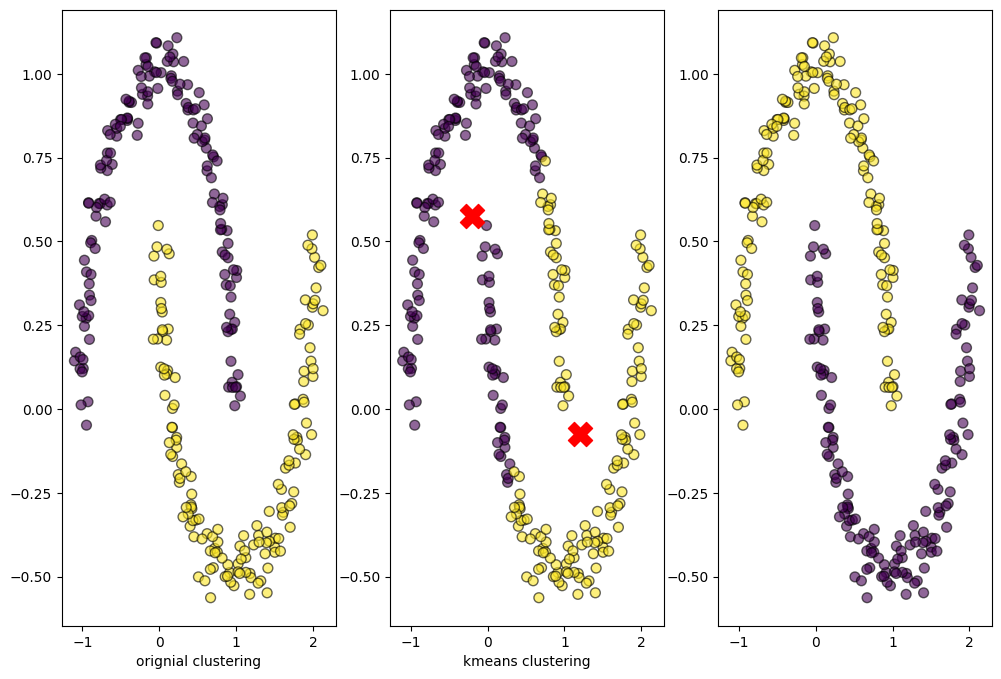

In [20]:
# Your code here
# Apply clustering algorithm and visualize results

# load dataset
# read dataset
# apply kmeans with 2
# apply DBSCAN
# visualize the result

# load dataset and read dataset
from sklearn.datasets import make_moons
x_moons,y_moons =  make_moons(n_samples=300,noise=0.05,random_state=42)

# apply kmeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, init= 'k-means++', n_init=5,random_state=42)
kmeans = kmeans.fit(x_moons)
klabels = kmeans.labels_
kcentroid = kmeans.cluster_centers_

# apply DBScan
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.2,min_samples=5,metric='euclidean')
dbscan.fit(x_moons)
dblables = dbscan.labels_

# visualize the result
import matplotlib.pyplot as plt
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(12,8))
orignal_clustering = axes[0].scatter(x_moons[:,0],x_moons[:,1],c=y_moons, s=50,cmap='viridis', alpha=0.6,edgecolor='k')
axes[0].set_xlabel("orignial clustering")

kmeans_clustering = axes[1].scatter(x_moons[:,0],x_moons[:,1],c=klabels, s=50,cmap='viridis', alpha=0.6,edgecolor='k')
axes[1].scatter(kcentroid[:,0],kcentroid[:,1],c='red',marker='X',s=300)
axes[1].set_xlabel("kmeans clustering")

dbscan_clustering = axes[2].scatter(x_moons[:,0],x_moons[:,1],c=dblables, s=50,cmap='viridis', alpha=0.6,edgecolor='k')

In [16]:
#help(plt.scatter)

## Problem 6: Concentric Circles with DBSCAN

**Dataset:** Two concentric circles (same as Problem 4)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Use the concentric circles data
1. Apply DBSCAN with appropriate parameters
2. Compare with K-Means results
3. Experiment with different eps values

**Hints:**
- Use `make_circles(n_samples=400, factor=0.5, noise=0.05, random_state=42)`
- Try `DBSCAN(eps=0.15, min_samples=5)`
- Visualize how eps affects clustering
- DBSCAN should separate inner and outer circles correctly

In [22]:
# We already have X_circles and y_circles from Problem 4

In [23]:
# Your code here
# Apply clustering algorithm and visualize results


## Problem 7: Clusters with Varied Density

**Dataset:** 3 clusters with different densities (400 samples)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Apply K-Means and DBSCAN
2. Compare their ability to handle density variations
3. Analyze the trade-offs

**Hints:**
- Use `make_blobs()` with `cluster_std=[0.5, 1.5, 3.0]` for different densities
- K-Means: `KMeans(n_clusters=3, random_state=42)`
- DBSCAN: `DBSCAN(eps=0.5, min_samples=5)`
- DBSCAN may struggle with varied densities (single eps for all clusters)

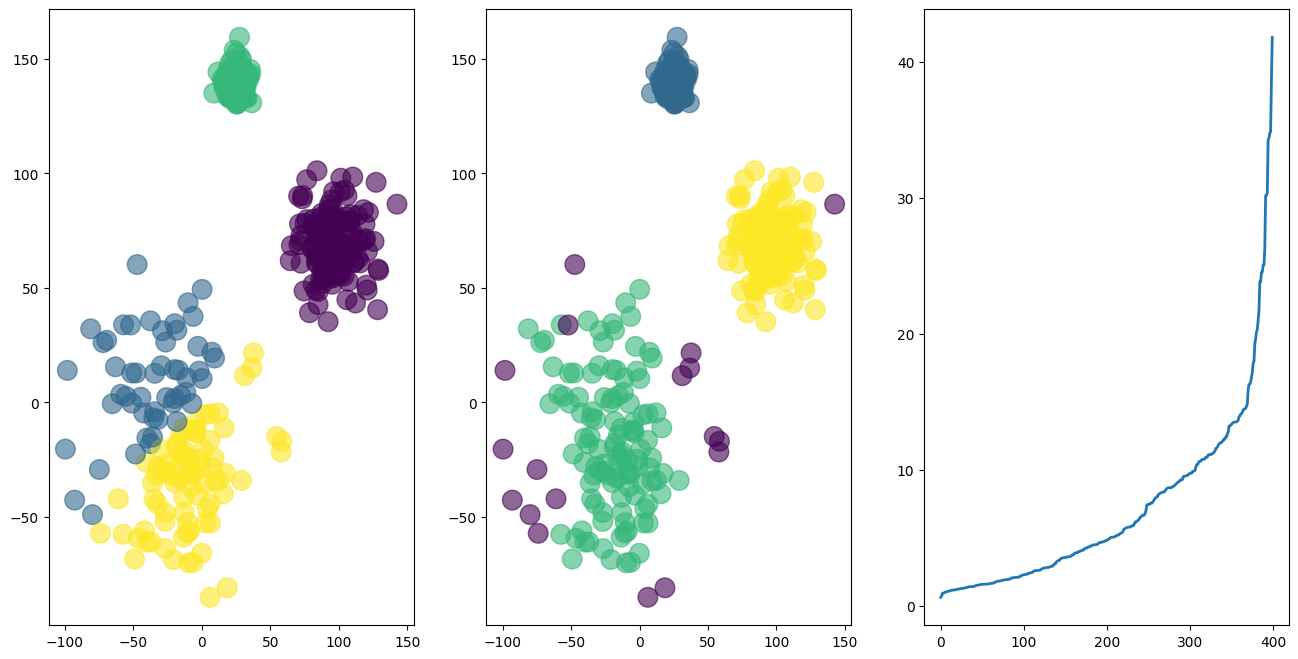

In [48]:
# step
# load dataset + read dataset
# apply kmeans
# apply dbscan

# load dataset + read dataset
from sklearn.datasets import make_blobs
X_customers , y_customers = make_blobs(n_samples=400, n_features=2, centers=3, cluster_std=[0.5, 1.5, 3.0],  random_state=42)

# Scale to realistic ranges
X_customers[:, 0] = X_customers[:, 0] * 10 + 50  # Annual Income: 30-70k
X_customers[:, 1] = X_customers[:, 1] * 10 + 50  # Spending Score: 30-70

# apply kmeans
from sklearn.cluster import KMeans
Kmeans = KMeans(n_clusters=4,  init='k-means++', n_init=5)
kmeans.fit(X_customers)
klevels = kmeans.labels_
centroid = kmeans.cluster_centers_

# apply DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=15, min_samples=5, metric='euclidean')
dbscan.fit(X_customers)
dblevel = dbscan.labels_

# visualization
import matplotlib.pyplot as plt
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,8))
axes[0].scatter(X_customers[:, 0],X_customers[:, 1],c= klevels, marker = 'o',s=200,alpha = 0.6)
axes[1].scatter(X_customers[:, 0],X_customers[:, 1],c= dblevel, cmap='viridis',marker = 'o',s=200,alpha = 0.6)

# Visualize DBSCAN concepts
from sklearn.neighbors import NearestNeighbors
import numpy as np
# K-distance graph for parameter selection
k = 5  # MinPts
nbrs = NearestNeighbors(n_neighbors=k).fit(X_customers)
distances, indices = nbrs.kneighbors(X_customers)
distances = np.sort(distances[:, k-1], axis=0)
axes[2].plot(distances, linewidth=2)

In [30]:
#help(DBSCAN)

In [4]:
# Generate varied density data
from sklearn.datasets import make_blobs
X_varied, y_varied = make_blobs(n_samples=400, n_features=2, centers=3, cluster_std=[0.5, 1.5, 3.0], random_state=42)

Text(0.5, 0, 'DBscan cluster')

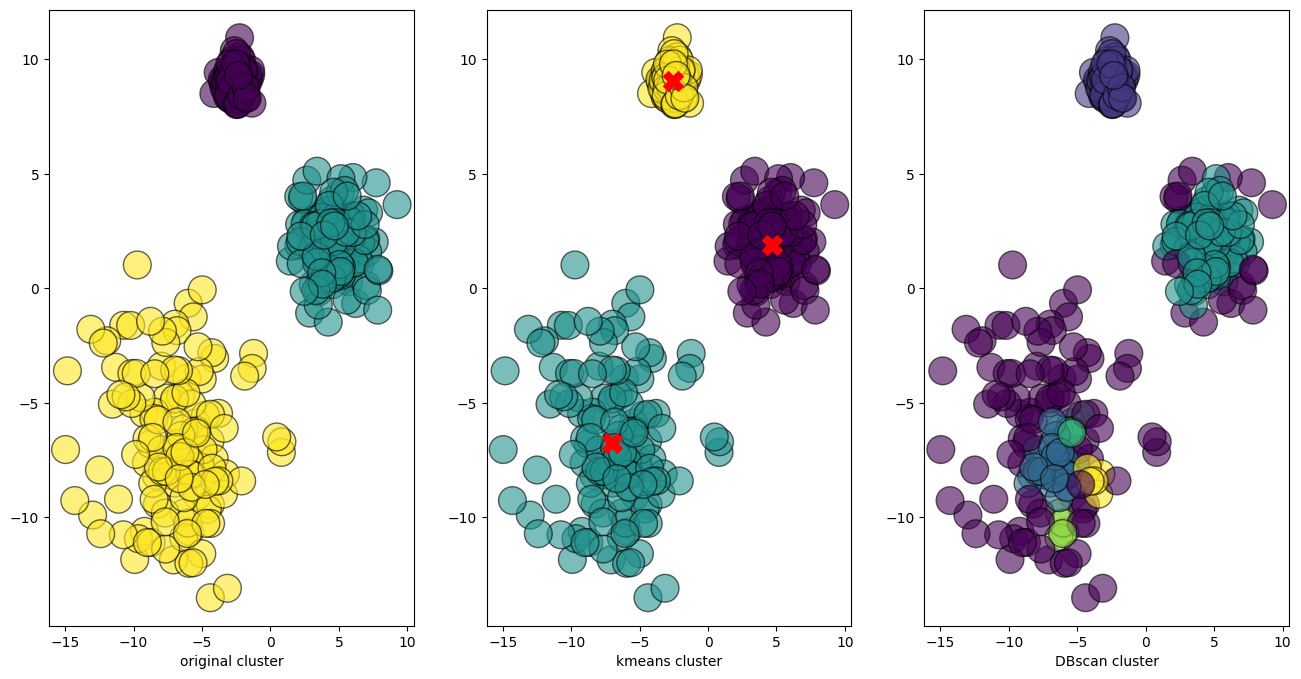

In [29]:
# Your code here
# Apply clustering algorithm and visualize results
# apply kmeans = 3
# apply dbscan
# visualize the result

# apply kmeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3,  init = "k-means++", n_init = 10)
kmeans.fit(X_varied)
labels = kmeans.labels_
cluser_center = kmeans.cluster_centers_

# apply DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5, metric='euclidean')
dbscan.fit(X_varied)
dblabels = dbscan.labels_


# visualziation
import matplotlib.pyplot as plt
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,8))

original_cluster = axes[0].scatter(X_varied[:,0],X_varied[:,1],c=y_varied,s=400,cmap='viridis',alpha=0.6,edgecolor='k')
axes[0].set_xlabel("original cluster")

kmeans_cluster = axes[1].scatter(X_varied[:,0],X_varied[:,1],c=labels,s=400,cmap='viridis',alpha=0.6,edgecolor='k')
axes[1].scatter(cluser_center[:,0],cluser_center[:,1],marker = 'X',c= 'red',s=200)
axes[1].set_xlabel("kmeans cluster")

dbscan_cluster = axes[2].scatter(X_varied[:,0],X_varied[:,1],c=dblabels,s=400,cmap='viridis',alpha=0.6,edgecolor='k')
axes[2].set_xlabel("DBscan cluster")

## Problem 8: Data with Outliers/Noise

**Dataset:** 3 well-separated clusters + random noise points (350 samples)

**Tasks:**
**Note:** Data is already generated for you. Focus on:
1. Apply K-Means and DBSCAN
2. Compare outlier detection capabilities
3. Analyze robustness to noise

**Hints:**
- Use `make_blobs()` for main clusters + `np.random.uniform()` for noise
- K-Means: `KMeans(n_clusters=3, random_state=42)`
- DBSCAN: `DBSCAN(eps=0.5, min_samples=5)`
- K-Means assigns all points to clusters (no outlier detection)
- DBSCAN labels outliers as -1 (noise)

In [33]:
import numpy as np
# Generate data with noise
np.random.seed(42)
X_clean, y_clean = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=0.6, random_state=42)

# Add noise points
noise_points = np.random.uniform(low=X_clean.min()-2, high=X_clean.max()+2, size=(50, 2))
X_noisy = np.vstack([X_clean, noise_points])
y_noisy = np.hstack([y_clean, np.full(50, -1)])  # -1 for noise

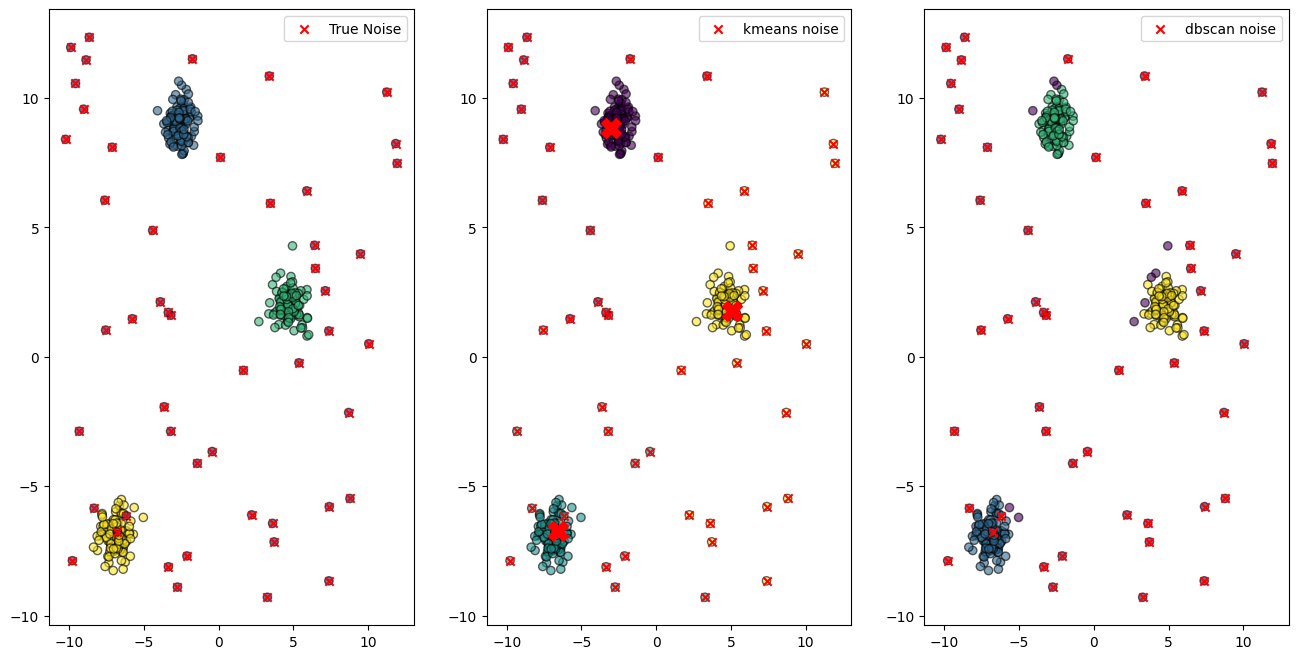

In [50]:
# Your code here
# Apply clustering algorithm and visualize results
# apply kmeans
# apply DBSCAN
# visualize the result

# apply kmeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,init='k-means++', n_init=5)
kmeans.fit(X_noisy)
labels = kmeans.labels_
centroid = kmeans.cluster_centers_

# apply dbscan
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5,min_samples=5, metric='euclidean')
dbscan.fit(X_noisy)
dblabels = dbscan.labels_

#visualization
import matplotlib.pyplot as plt
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,8))

# original_cluster
original_cluster = axes[0].scatter(X_noisy[:,0],X_noisy[:,1],c=y_noisy, cmap = 'viridis', alpha = 0.6 , edgecolor='k' )
noisy_cluster = axes[0].scatter(X_noisy[y_noisy==-1,0],X_noisy[y_noisy==-1,1],c='red',marker='x',label='True Noise')
axes[0].legend()

#kmeans cluster
kmeans_cluster = axes[1].scatter(X_noisy[:,0],X_noisy[:,1],c=labels, cmap = 'viridis', alpha = 0.6 , edgecolor='k')
axes[1].scatter(centroid[:,0],centroid[:,1],marker='X',c='red',s=200)
kmeans_noise = axes[1].scatter(X_noisy[y_noisy==-1,0],X_noisy[y_noisy==-1,1],c='red',marker='x',label = 'kmeans noise')
axes[1].legend()

#dbscan cluster
dbscan_cluster = axes[2].scatter(X_noisy[:,0],X_noisy[:,1],c=dblabels, cmap = 'viridis', alpha = 0.6 , edgecolor='k')
dbscan_noise = axes[2].scatter(X_noisy[y_noisy==-1,0],X_noisy[y_noisy==-1,1],c='red',marker='x',label = 'dbscan noise')
axes[2].legend()

## Hireachical Clustering

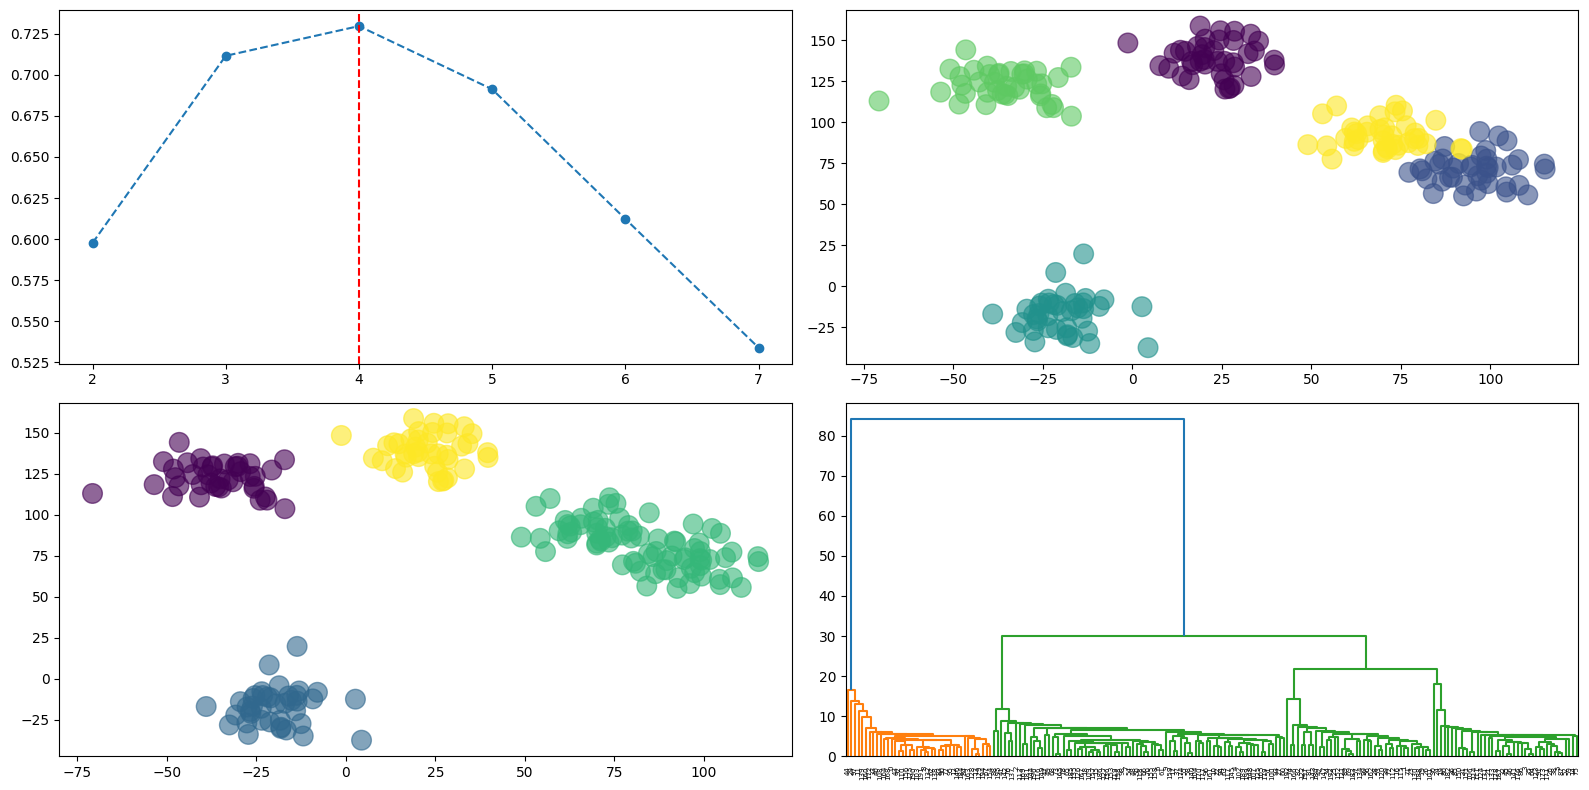

In [20]:
# steps
# load + read dataset
# apply AgglomerativeClustering
# sketch dendogram


# load + read dataset
from sklearn.datasets import make_blobs
X_customers,y_customers= make_blobs(n_samples=200, n_features=2,centers=5,cluster_std=1.0,random_state=42)

# scale to realistic ranges
X_customers[:,0] = X_customers[:,0]*10 + 50 # Annual Income: 30-70k
X_customers[:,1] = X_customers[:,1]*10 + 50 # Spending Score: 30-70

# choosing the right number of clusters
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
silhouette = []
cluster_range = range(2,8)
for i in range (2,8):
    agg_cluster = AgglomerativeClustering(n_clusters=i, metric='euclidean',linkage='single')
    agg_cluster.fit(X_customers)
    labels = agg_cluster.labels_
    silhouette.append(silhouette_score(X=X_customers,labels=labels))

# plot the score
import matplotlib.pyplot as plt
fig,axes= plt.subplots(nrows=2,ncols=2,figsize=(16,8))
sil_plot = axes[0,0].plot(cluster_range,silhouette,marker='o',linestyle='--')
axes[0,0].axvline(x=4,color='r',linestyle = '--')

# apply AgglomerativeClustering for clusters = 4
agg_cluster = AgglomerativeClustering(n_clusters=4, metric='euclidean',linkage='single')
agg_cluster.fit(X_customers)
labels= agg_cluster.labels_

# clustering plot
orignal_cluster = axes[0,1].scatter(X_customers[:,0],X_customers[:,1],c=y_customers, marker='o',alpha = 0.6,s=200)
agg_cluster = axes[1,0].scatter(X_customers[:,0],X_customers[:,1],c=labels, marker='o',alpha = 0.6,s=200)

# linkage matrix + dendogram
from scipy.cluster.hierarchy import linkage,  dendrogram
linkage_matrix = linkage(y=X_customers, method='single', metric='euclidean')
dendrogram(Z= linkage_matrix,ax= axes[1,1])
plt.tight_layout()
plt.show()

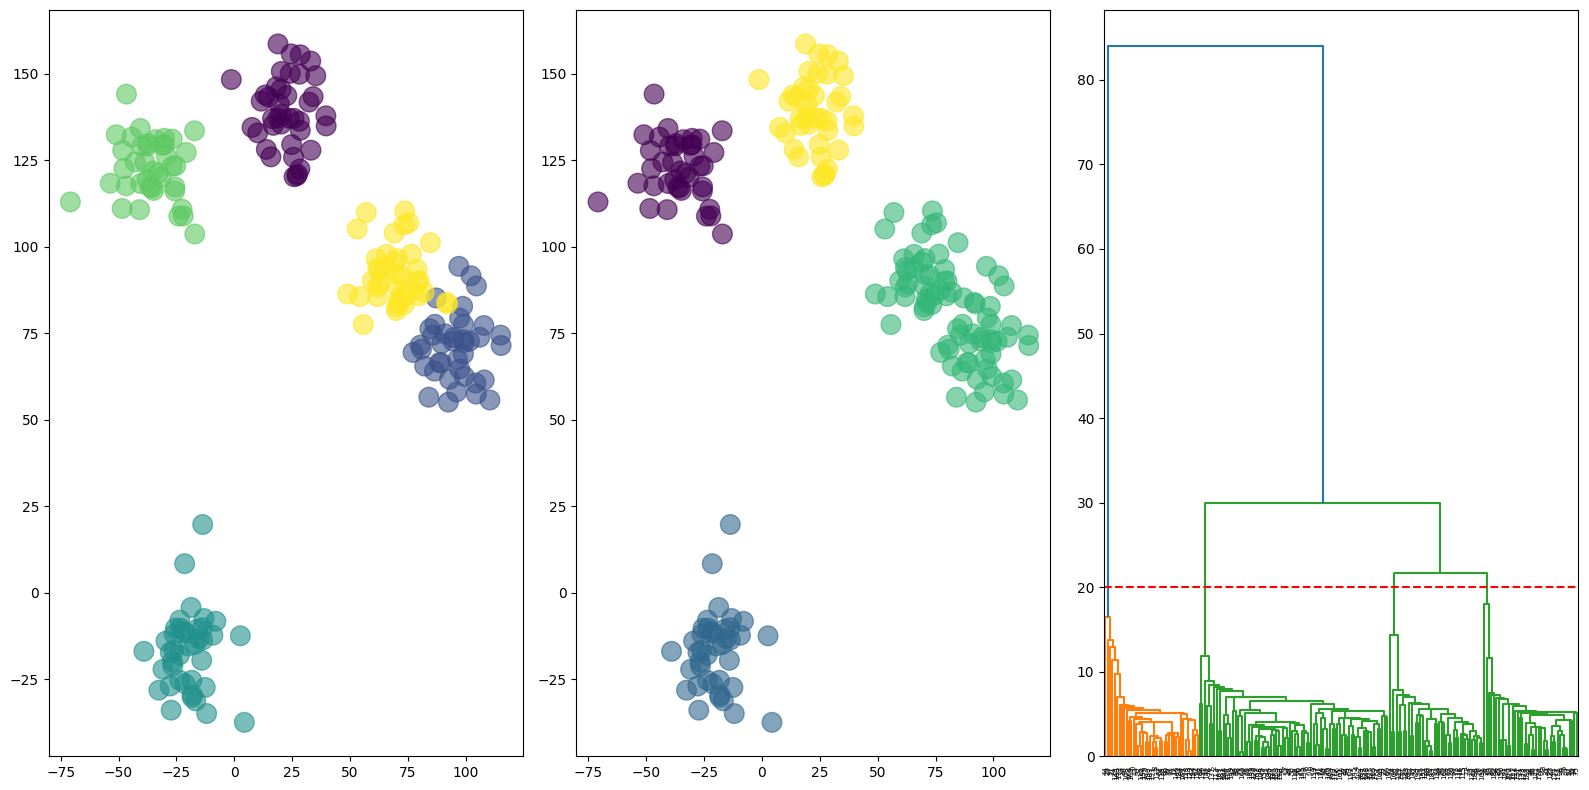

In [58]:
# load datset
# read dataset
# apply AgglomerativeClustering
# sketch dendogram

# load dataset
from sklearn.datasets import make_blobs
X_customers,y_customers = make_blobs(n_samples=200,n_features=2,centers=5,cluster_std=1.0,random_state=42)

# scale to realistic ranges
X_customers[:,0] = X_customers[:,0]*10 + 50 # Annual Income: 30-70k
X_customers[:,1] = X_customers[:,1]*10 + 50 # Spending Score: 30-70

# apply AgglomerativeClustering
from sklearn.cluster import AgglomerativeClustering
agg_cluster = AgglomerativeClustering(n_clusters=4,metric='euclidean',linkage='single')
agg_cluster.fit(X_customers)
labels = agg_cluster.labels_

#visualize cluster
import matplotlib.pyplot as plt
fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(16,8))
original_cluster = axes[0].scatter(X_customers[:,0],X_customers[:,1],c=y_customers,cmap='viridis',alpha=0.6,s=200 )

single_linkage_clustering = axes[1].scatter(X_customers[:,0],X_customers[:,1],c=labels,cmap='viridis',alpha=0.6,s=200)

# dendogram
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_matrix = linkage(X_customers, method='single')
dendrogram(linkage_matrix, ax=axes[2])
axes[2].axhline(y=20, color='r', linestyle='--', label='Cut at height 4 (3 clusters)')
plt.tight_layout()
plt.show()

---
# Summary: When to Use Each Algorithm

## K-Means
✅ **Use when:**
- Clusters variance are equal in all directions
- Clusters are spherical/globular
- Clusters are similar in size
- Number of clusters is known
- Fast computation is needed
- Data has no outliers

❌ **Avoid when:**
- Clusters have arbitrary shapes (moons, circles)
- Clusters have very different sizes or densities
- Data contains many outliers
- Number of clusters is unknown

## DBSCAN
✅ **Use when:**
- Clusters have arbitrary shapes
- Number of clusters is unknown
- Data contains outliers/noise
- Outlier detection is important
- Clusters are well-separated by density

❌ **Avoid when:**
- Clusters have very different densities
- High-dimensional data (curse of dimensionality)
- Parameters (eps, min_samples) are hard to tune
- All points must be assigned to clusters

## Key Takeaways
1. **No single algorithm is best for all data**
2. **Visualize your data** before choosing an algorithm
3. **K-Means**: Fast, simple, but assumes spherical clusters
4. **DBSCAN**: Flexible shapes, detects outliers, but sensitive to parameters
5. **Always evaluate** with metrics (silhouette score, visual inspection)
6. **Consider domain knowledge** when interpreting results

---
**End of Tutorial**